# Canadian Mineral Production Analysis
### CMSC320 Spring 2026 Final Project

---

**Contributions:**

| Member | Sections | Summary |
|--------|----------|---------|
| Eric | B, C | Contributed to Metallic/Non-metallic quantity product comparisons. |
| Jon | B, C | Worked on the metallic/non-metallic value comparisons. |
| Tejas | B, C | Worked on the annual mineral quantity vs value datasets. |
| Boubacar | C, F, G | Worked on statistical findings, insights, conclusions, overall document formatting & content overview. |

A: Whole group decided on this idea for metallic and non-metallic products with their quantity and value.

## Introduction

Minerals are an important part of Canada's economy, because they are used in construction, manufacturing, technology, trade, and a bunch of other industries. However, not all minerals contribute to the economy in the same way. Some minerals may be produced in very large quantities, but have lower shipment values, while others can have few quantities, but much higher value. As a group, we hope to take these datasets about mineral production in order to better understand how metallic and non-metallic minerals differ in production quality, shipment value, and overall economic contribution.

**This project is guided by three main questions.**

The first being "Do metallic and non-metallic minerals differ significantly in their production quantities?". Comparing distributions helps show whether they should be analyzed together or treated as separate parts due to their differing production scales within the Canadian mining sector.

The second is "Is there a strong relationship between mineral production quantity and shipment value?". Apart from whether a material is rare or not, this question matters because it tests whether producing more of a mineral necessarily means generating more economic value. If quantity and value are weakly related, then other factors such as supply/demand, price per unit, industrial usage may be a more important factor.

The final is "Has Canada's overall mineral value changed significantly in recent years compared to 2019?". Setting aside the obvious yes/no answer, this matters because it helps identify which minerals have gained importance over the years and whether this can be evaluated in a statistically meaningful way.

**Data sources:** Statistics Canada, Tables [16-10-0019-01](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1610001901), [16-10-0019-02](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1610001902), [16-10-0020-01](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1610002001), [16-10-0022-01](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1610002201), [16-10-0022-02](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1610002202)

---
## Data Processing

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

### Quantity and value of metallic materials (Monthly)
Jon's dataset tracks monthly production quantities and shipment values for metallic minerals across Canada

### Combined Metallic & Non-Metallic Monthly Quantities (Eric)

Eric built a reusable loader that handles both the metallic and non-metallic quantity CSVs. It extracts measurement units from parentheses, cleans product names, and tags each row with its mineral category.

In [12]:
def load_statcan_monthly_quantity(filename, category_name):
    df = pd.read_csv(filename, skiprows=8, header=1) # format of the csv file has some garbage lines for the first 8 rows at the top
    df["Products"] = df["Products"].ffill() # some products are NaN but they really belong to the same Product until a fresh one is listed so this just carries them down
    df = df.replace(["..", "x"], np.nan) # actually does the replacing

    df = df.melt(
        id_vars = ["Products", "Variables"],
        var_name = "REF_DATE", # month columns become reference date
        value_name = "VALUE" # their actual entries will become the value
    )

    df = df.dropna(subset=["VALUE"]).copy() # drop missing values

    df["VALUE"] = df["VALUE"].astype(str).str.replace(",", "", regex=False) # remove commas from "numbers"
    df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce") # convert value column (string) to numbers
    df = df.dropna(subset=["VALUE"]).copy() # drop rows where value failed to convert to number

    df["REF_DATE"] = pd.to_datetime(df["REF_DATE"], format="%B %Y", errors="coerce") # convert date strings to actual date time objects
    df = df.dropna(subset=["REF_DATE"]).copy() # dropping invalid dates

    df["Unit"] = df["Products"].str.extract(r"\((.*?)\)") # extract unit of measurement (metric tonnes)
    df["Product_Name"] = ( # creates a cleaner product name by removing the unit in parantheses, trailing numbers, and whitespace (that appears)
        df["Products"].str.replace(r"\s*\(.*?\)", "", regex=True)
        .str.replace(r"\s+\d+$", "", regex=True).str.strip()
    )

    df["Category"] = category_name # this is just for non-metallic vs metallic naming
    return df

### Annual Mineral Production: Quantity & Value (Tejas)

Tejas's dataset provides a year-level view from 2019 to 2025, covering all mineral categories. It's used to compute total national production quantities and shipment values for each year.

In [13]:
df_qty = pd.read_csv('canada_annual_quantities.csv', skiprows = 8, header = 1)
df_val = pd.read_csv('canada_annual_values.csv', skiprows = 9, header = 1)

df_qty = df_qty.replace(['..', 'x'], np.nan)
df_val = df_val.replace(['..', 'x'], np.nan)

In [14]:
years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']
quantities = []
values = []

for year in years:
    qty = pd.to_numeric(df_qty[year].astype(str).str.replace(',', '').str.replace('p', ''), errors = 'coerce').sum()
    val = pd.to_numeric(df_val[year].astype(str).str.replace(',', '').str.replace('p', ''), errors = 'coerce').sum()
    quantities.append(qty)
    values.append(val)

summary = pd.DataFrame({
    'Year': [int(y) for y in years],
    'Total_Quantity': quantities,
    'Total_Value_CAD_1000s': values
})

print(summary)

   Year  Total_Quantity  Total_Value_CAD_1000s
0  2019    2.165204e+09            158631345.0
1  2020    2.321877e+09            163015135.0
2  2021    2.566518e+09            191282564.0
3  2022    2.774921e+09            223359859.0
4  2023    2.705729e+09            197943726.0
5  2024    3.021890e+09            193909864.0
6  2025    1.926167e+09            180875883.0


### Metallic & Non-Metallic Monthly Values (Jon)

In [15]:
metallic_val_df = pd.read_csv('Metallic Value.csv', skiprows=10)
metallic_val_df = metallic_val_df.iloc[:-20]
metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

metallic_val_df = metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
metallic_val_df['Value'] = pd.to_numeric(metallic_val_df['Value'].str.replace(',', ''))
metallic_val_df.dropna(inplace=True)
metallic_val_df = metallic_val_df[metallic_val_df['Value'] > 0]

metallic_mean = metallic_val_df['Value'].mean()
metallic_mean

np.float64(676947726.5590551)

In [16]:
non_metallic_val_df = pd.read_csv('Non-Metallic Value.csv', skiprows=10)
non_metallic_val_df = non_metallic_val_df.iloc[:-14]
non_metallic_val_df.replace({'..': float('nan'), 'x': float('nan')}, inplace=True)

non_metallic_val_df = non_metallic_val_df.melt(
    id_vars='Products',
    var_name='Month',
    value_name='Value'
)
non_metallic_val_df['Value'] = pd.to_numeric(non_metallic_val_df['Value'].str.replace(',', ''))
non_metallic_val_df.dropna(inplace=True)
non_metallic_val_df = non_metallic_val_df[non_metallic_val_df['Value'] > 0]

non_metallic_mean = non_metallic_val_df['Value'].mean()
non_metallic_mean

np.float64(131743784.64102565)

In [17]:
metallic_df = load_statcan_monthly_quantity("1610001901-eng.csv", "Metallic")
nonmetallic_df = load_statcan_monthly_quantity("1610002001-eng.csv", "Non-metallic")

combined_df = pd.concat([metallic_df, nonmetallic_df], ignore_index=True)

quantity_df = combined_df[combined_df["Unit"].str.contains("metric tonnes", case=False, na=False)].copy()

produced_df = quantity_df[quantity_df["Variables"].str.contains("produced", case=False, na=False)].copy()

combined_produced_df = produced_df

---
## Exploratory Data Analysis

### Average Monthly Production by Category (Eric)

The charts below compare average monthly production volumes between metallic and non-metallic minerals

Average monthly quantity produced by category:
Category
Metallic        948986.847525
Non-metallic    381142.471831
Name: VALUE, dtype: float64


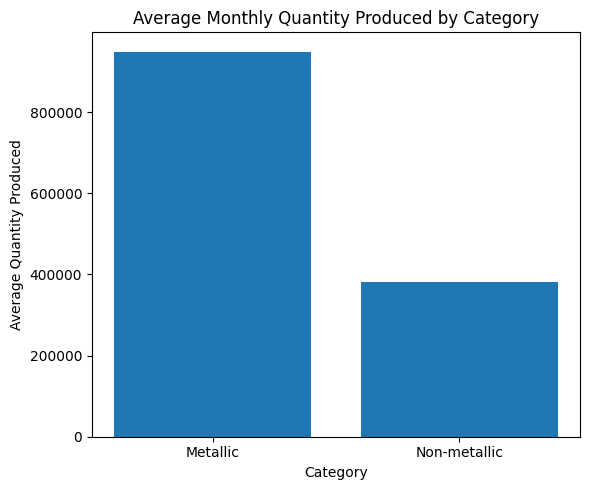

In [18]:
category_avg = ( # average monthly production for each category calculation
    produced_df.groupby("Category")["VALUE"].mean().sort_values(ascending=False)
)

print("Average monthly quantity produced by category:") # displaying averages for reference
print(category_avg)

plt.figure(figsize=(6, 5)) # plot stuff
plt.bar(category_avg.index, category_avg.values)
plt.title("Average Monthly Quantity Produced by Category")
plt.xlabel("Category")
plt.ylabel("Average Quantity Produced")
plt.tight_layout()
plt.show()

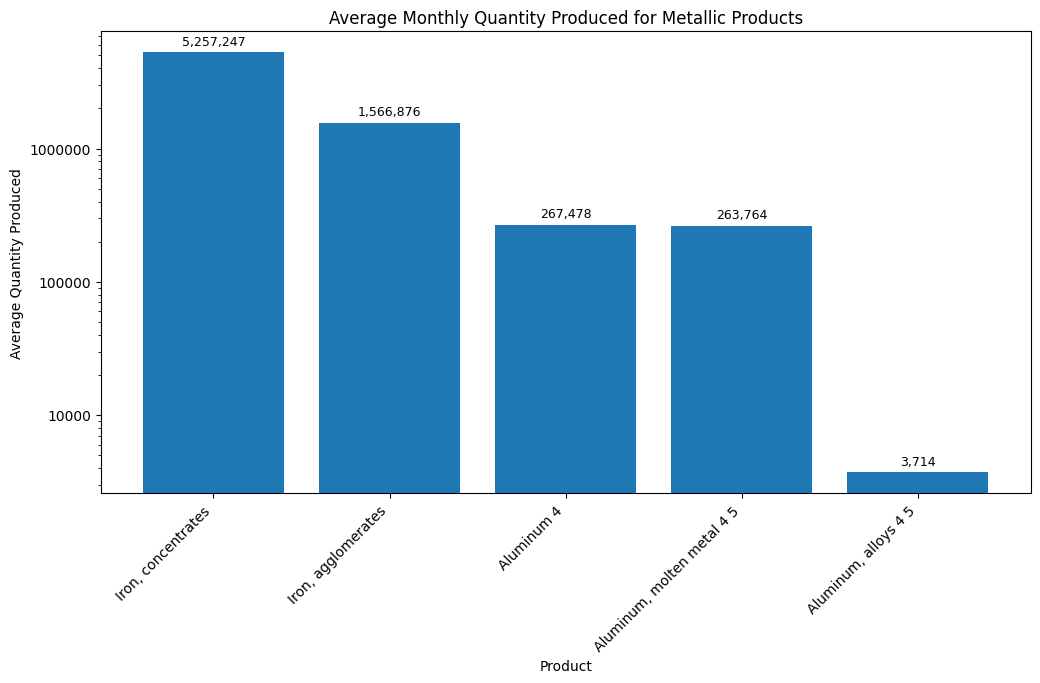

In [19]:
metallic_avg = ( # compute for average monthly production for each metallic product
    produced_df[produced_df["Category"] == "Metallic"].groupby("Product_Name")["VALUE"].mean().sort_values(ascending=False)
)

metallic_positive = metallic_avg[metallic_avg > 0] # keep positive average values (doesnt make sense to produce a negative amount)

plt.figure(figsize=(12, 6))
bars = plt.bar(metallic_positive.index, metallic_positive.values)

plt.yscale("log") # log scale cause it wasn't really showing all the differences in a natural way
plt.title("Average Monthly Quantity Produced for Metallic Products")
plt.xlabel("Product")
plt.ylabel("Average Quantity Produced")
plt.xticks(rotation=45, ha="right")

# formats y-axis as regular numbers instead of using scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

# add average value as text above each bar (not entirely sure if this is needed?)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize = 9
    )

plt.tight_layout
plt.show()

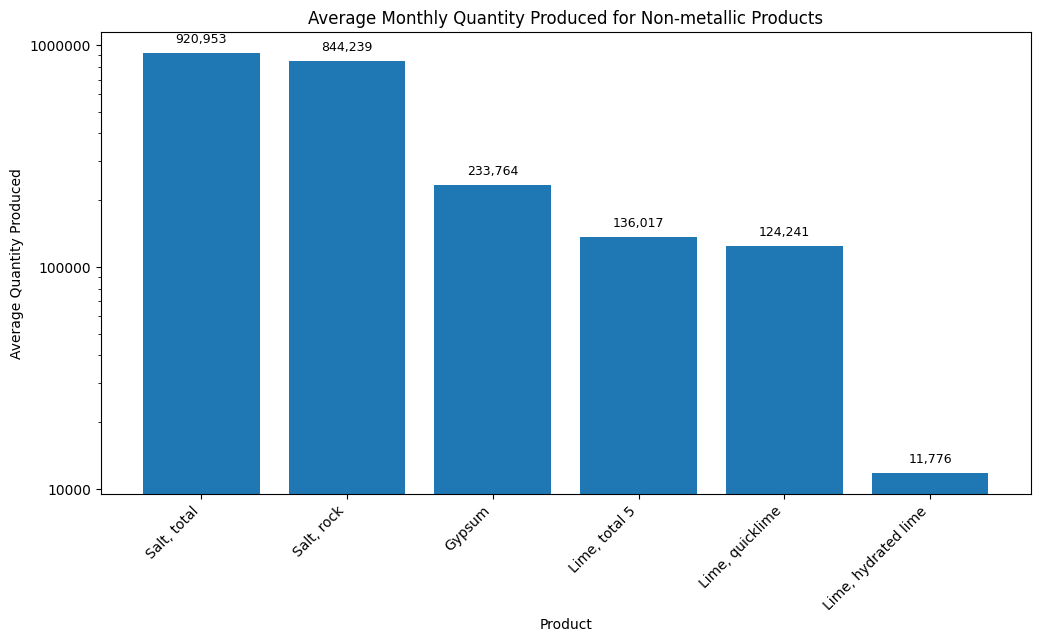

In [20]:
nonmetallic_avg = ( # compute for average monthly production for each nonmetallic product
    produced_df[produced_df["Category"] == "Non-metallic"].groupby("Product_Name")["VALUE"].mean().sort_values(ascending=False)
)

nonmetallic_positive = nonmetallic_avg[nonmetallic_avg > 0] # keep positive average values (doesnt make sense to produce a negative amount)

plt.figure(figsize=(12, 6))
bars = plt.bar(nonmetallic_positive.index, nonmetallic_positive.values)

plt.yscale("log") # log scale cause it wasn't really showing all the differences in a natural way
plt.title("Average Monthly Quantity Produced for Non-metallic Products")
plt.xlabel("Product")
plt.ylabel("Average Quantity Produced")
plt.xticks(rotation=45, ha="right")

# formats y-axis as regular numbers instead of using scientific notation
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style="plain", axis="y")

# add average value as text above each bar (not entirely sure if this is needed?)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize = 9
    )

plt.tight_layout
plt.show()

### Annual Quantity vs. Value Correlation (Tejas)

The scatter plot below shows total Canadian mineral production quantity against total shipment value for each year from 2019 to 2025. Each point is labeled with its year, and a trend line is fitted to show the overall direction.

In [21]:
correlation = summary['Total_Quantity'].corr(summary['Total_Value_CAD_1000s'])
print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.663


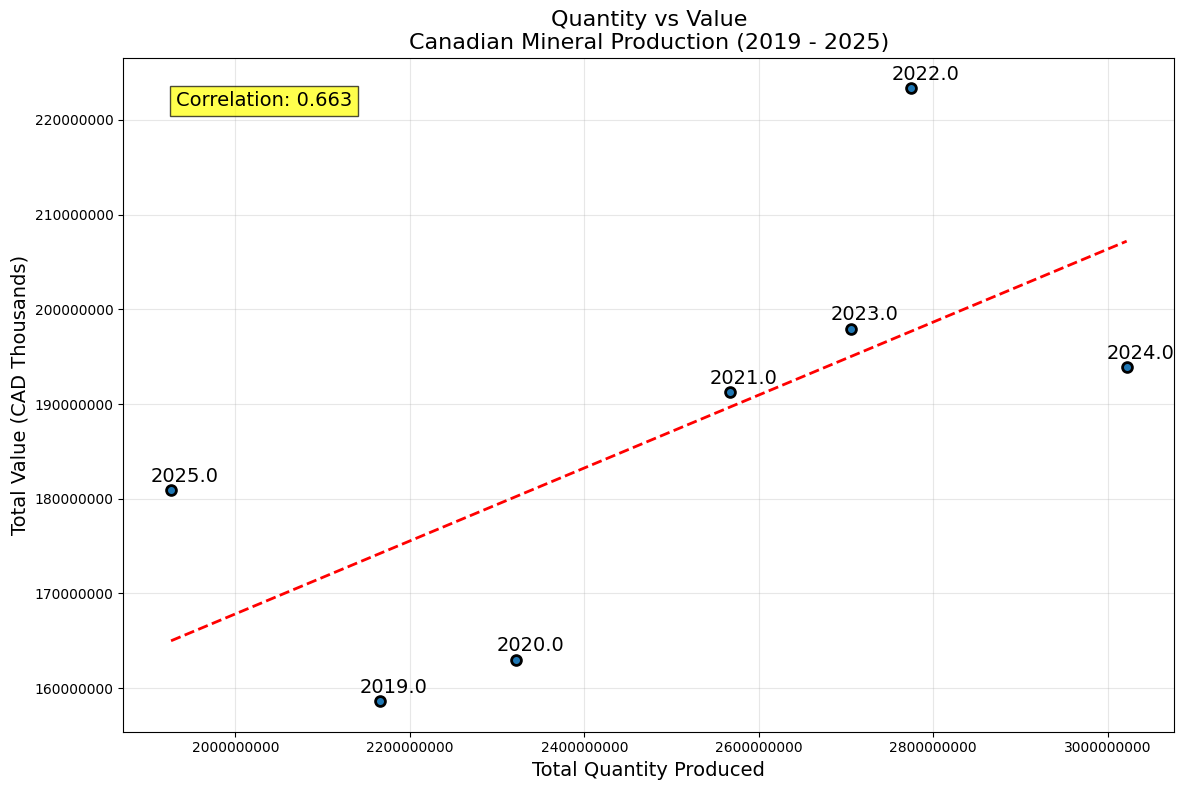

In [22]:
plt.figure(figsize = (12, 8))

plt.scatter(summary['Total_Quantity'], summary['Total_Value_CAD_1000s'], s = 50, edgecolors = 'black', linewidth = 2)

for idx, row in summary.iterrows():
    plt.annotate(
        str(row['Year']),
        (row['Total_Quantity'], row['Total_Value_CAD_1000s']),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=14,
        ha='center',
        va='center'
    )
z  =  np.polyfit(summary['Total_Quantity'], summary['Total_Value_CAD_1000s'], 1)
p  =  np.poly1d(z)

x_line  =  np.linspace(summary['Total_Quantity'].min(), summary['Total_Quantity'].max(), 50)
plt.plot(x_line, p(x_line), 'r--', linewidth = 2)

plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform = plt.gca().transAxes,
         fontsize = 14, bbox = dict(facecolor = 'yellow', alpha = 0.7), verticalalignment = 'top')

plt.ticklabel_format(style = 'plain', axis = 'both')

plt.xlabel('Total Quantity Produced', fontsize = 14)
plt.ylabel('Total Value (CAD Thousands)', fontsize = 14)
plt.title('Quantity vs Value\nCanadian Mineral Production (2019 - 2025)', fontsize = 16)

plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

### Metallic vs. Non-Metallic Value Comparison (Jon)

The bar chart shows the average monthly shipment value for each category. The box plot below it shows the full distribution of monthly values on a log scale, making it easier to see the spread within each group.

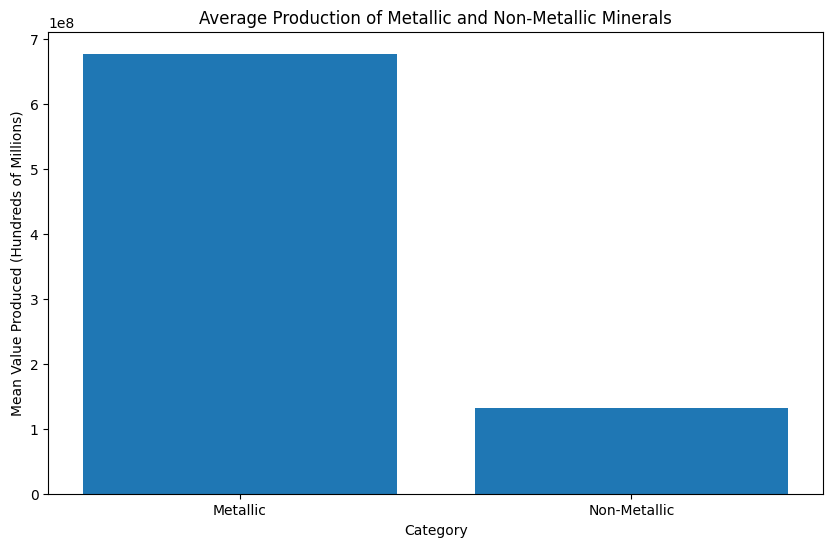

In [23]:
ids = ['Metallic', 'Non-Metallic']
mean_values = [metallic_mean, non_metallic_mean]

plt.figure(figsize=(10, 6))
plt.bar(ids, mean_values)
plt.title('Average Production of Metallic and Non-Metallic Minerals')
plt.xlabel('Category')
plt.ylabel('Mean Value Produced (Hundreds of Millions)')
plt.yticks
plt.show()

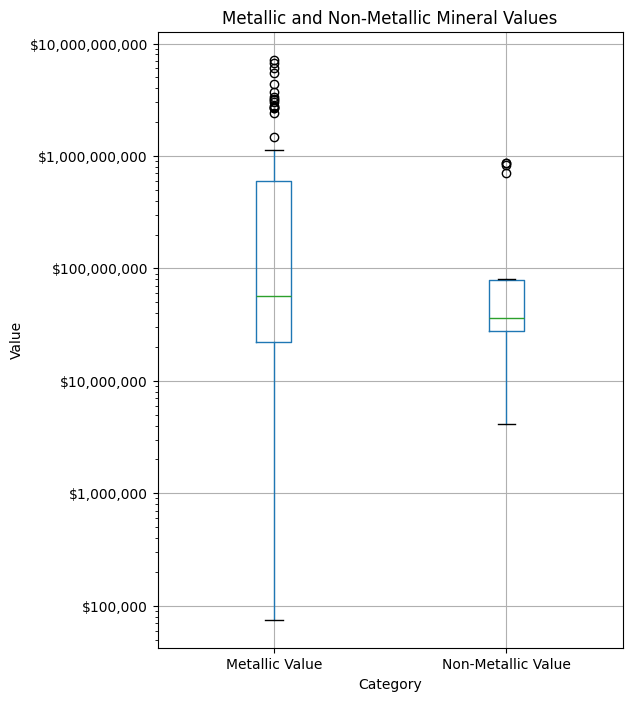

In [24]:
values_df = pd.DataFrame()
values_df['Metallic Value'] = metallic_val_df['Value']
values_df['Non-Metallic Value'] = non_metallic_val_df['Value']
boxplot = values_df.boxplot(column=['Metallic Value', 'Non-Metallic Value'], figsize=(6, 8))
plt.title('Metallic and Non-Metallic Mineral Values')
plt.xlabel('Category')
plt.ylabel('Value')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

---
## Conclusion 1: Metallic minerals are produced in different quantities than non metallic materials

**Mann-Whitney U test** to determine whether difference is statistically significant

Null hypothesis: Distribution is same for metallic and non metallic minerals

Alternative hypothesis: Distribution is different

In [25]:
metallic_values = combined_produced_df[combined_produced_df["Category"] == "Metallic"]["VALUE"].dropna()
nonmetallic_values = combined_produced_df[combined_produced_df["Category"] == "Non-metallic"]["VALUE"].dropna()

print(f"Metallic observations: {len(metallic_values)}")
print(f"Non-metallic observations: {len(nonmetallic_values)}")
print(f"\nMetallic median: {metallic_values.median():,.0f}")
print(f"Non-metallic median: {nonmetallic_values.median():,.0f}")
print(f"Metallic mean: {metallic_values.mean():,.0f}")
print(f"Non-metallic mean: {nonmetallic_values.mean():,.0f}")

# test
u_stat, p_value = stats.mannwhitneyu(metallic_values, nonmetallic_values, alternative='two-sided')
print(f"\nMann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value: {p_value:.6f}")




Metallic observations: 505
Non-metallic observations: 426

Metallic median: 238,002
Non-metallic median: 157,898
Metallic mean: 948,987
Non-metallic mean: 381,142

Mann-Whitney U statistic: 84,898
p-value: 0.000000


Due to p-value under 0.05, we can conclude that the difference in production quantity distributions of metallic and non-metallic minerals are significant, which means that the two categories represent different scales of production in Canada's mining sector.

## Conclusion 2: Production quantity and shipment value are not strongly correlated among metallic minerals

**Pearson correlation w/ hypothesis test** to determine whether statistically significant

Null hypothesis: No linear association between avg monthly quantity and avg monthly value (p = 0)

Alternative hypothesis: There is linear association (p != 0)

In [26]:
# Using tejas data, match quantity produced with value per mineral

df_qty['Products'] = df_qty['Products'].ffill()
df_qty['Variables'] = df_qty['Variables'].ffill()
qty_produced_annual = df_qty[df_qty['Variables'] == 'Quantity produced'].copy()

def clean_name(s):
    s = re.sub(r'\s*\(.*?\)', '', str(s))
    s = re.sub(r'(\s+\d+)+$', '', s)
    return s.lower().strip()

years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

qty_avgs = {}
for _, row in qty_produced_annual.iterrows():
    vals = [pd.to_numeric(str(row.get(y, '')).replace(',', '').replace('p', ''), errors='coerce') for y in years]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        qty_avgs[clean_name(row['Products'])] = np.mean(vals)

val_avgs = {}
for _, row in df_val.iterrows():
    vals = [pd.to_numeric(str(row.get(y, '')).replace(',', '').replace('p', ''), errors='coerce') for y in years]
    vals = [v for v in vals if not np.isnan(v)]
    if vals:
        val_avgs[clean_name(row['Products'])] = np.mean(vals)

common = set(qty_avgs.keys()) & set(val_avgs.keys())
common = {k for k in common if qty_avgs[k] > 0 and val_avgs[k] > 0}

paired_df = pd.DataFrame({
    'AvgQuantity': [qty_avgs[k] for k in common],
    'AvgValue': [val_avgs[k] for k in common]
}, index=list(common))

print(f"Matched minerals with both quantity and value: {len(paired_df)}")

r_pearson, p_pearson = stats.pearsonr(paired_df['AvgQuantity'], paired_df['AvgValue'])
print(f"\nPearson r = {r_pearson:.4f}")
print(f"p-value = {p_pearson:.6f}")


Matched minerals with both quantity and value: 50

Pearson r = 0.0470
p-value = 0.745653


Pearson r ≈ 0.05 with p = 0.75,  therefore no linear relationship between how much of a mineral Canada produces and how much revenue it generates.

## Conclusion 3: Recent overall mineral production is significantly different from 2019

Use **One-sample t-test**

Null hypothesis: Mean total value from 2020-2025 is same as 2019 total value


Alternative hypothesis: Mean total value from 2020-2025 is different from 2019 total value

In [27]:
# Using tejas DataFrame
print("Year-over-year totals:")
print(summary.to_string(index=False))

baseline_value = summary.loc[summary['Year'] == 2019, 'Total_Value_CAD_1000s'].values[0]
print(f"\n2019 baseline total value (CAD thousands): {baseline_value:,.0f}")

later_years_values = summary.loc[summary['Year'] > 2019, 'Total_Value_CAD_1000s'].values
print(f"2020-2025 values: {later_years_values}")
print(f"Mean of 2020-2025: {later_years_values.mean():,.0f}")

t_stat, p_value = stats.ttest_1samp(later_years_values, baseline_value)
print(f"\nOne-sample t-test:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")


Year-over-year totals:
 Year  Total_Quantity  Total_Value_CAD_1000s
 2019    2165203912.0            158631345.0
 2020    2321876634.0            163015135.0
 2021    2566517536.0            191282564.0
 2022    2774920555.0            223359859.0
 2023    2705728700.0            197943726.0
 2024    3021889806.0            193909864.0
 2025    1926166504.0            180875883.0

2019 baseline total value (CAD thousands): 158,631,345
2020-2025 values: [1.63015135e+08 1.91282564e+08 2.23359859e+08 1.97943726e+08
 1.93909864e+08 1.80875883e+08]
Mean of 2020-2025: 191,731,172

One-sample t-test:
t-statistic: 4.0678
p-value: 0.0097


With significance level of 0.05, we reject null hypothesis. This confirms that the average total mineral value from 2020–2025 is significantly higher than the 2019 baseline which means Canada's mineral sector experienced an increase in total economic output.

---
## Primary Analysis

### Method

Due to the results of our exploratory analysis, we decided to choose Linear Regression as main machine learning technique.

Linear Regression is optimal here because our vital questions of production quantity, shipment value, and total annual mineral value all involve numerical outcomes.

Our previous tests such as Mann-Whitney U, Pearson correlation, and one sample t-test were able to tell us whether a relationship was significant, but they didn't tell us how strong they were, which linear regression does tell us by quantifying the relationship.

#### Q1: Do metallic and non-metallic minerals differ significantly in their production quantities?

For this, we encode mineral category as a binary variable (Metallic = 0, Non-metallic = 1) and use it to predict production quantity. This extends the Mann-Whitney U test by putting a number on the difference between the two groups instaed of just confirming the difference exists.

In [28]:
reg_df = combined_produced_df[['Category', 'VALUE']].dropna().copy()
reg_df['mineral_type'] = reg_df['Category'].map({'Metallic': 0, 'Non-metallic': 1})

model_q1 = LinearRegression()
model_q1.fit(reg_df[['mineral_type']], reg_df['VALUE'])

print(f"Coefficient: {model_q1.coef_[0]:,.2f}")
print(f"Intercept: {model_q1.intercept_:,.2f}")
print(f"R²: {r2_score(reg_df['VALUE'], model_q1.predict(reg_df[['mineral_type']])):.4f}")

Coefficient: -567,844.38
Intercept: 948,986.85
R²: 0.0409


On average, non-metallic minerals are produced in around 568,000 fewer metric tons per month than metallic ones.

This coincides with what the bar charts showed us, metallic minerals are much higher in volume, and our Mann-Whitney U test confirmed that this difference was statistically significant (p < 0.05).

The category alone only explains around 4% of the variation in production quantity since there's a large spread within each group. For example, iron and gold are both metallic but their volumes are very different. HOwever, the linear regression is able to quantify the gap in a way that the Mann-Whitney test couldn't.

#### Q2: Is there a strong relationship between mineral production quantity and shipment value?

To formally test whether production quantity can predict shipment value, we split the paired mineral dataset into a training set (80%) and a test
set (20%), trained a linear regression model on the training set, and evaluated its
performance on the unseen test set. This approach ensures that the model's performance
is assessed on data it has never seen, which is the standard way of evaluating whether
a predictive relationship genuinely exists.

In [29]:
X = paired_df[['AvgQuantity']]
y = paired_df['AvgValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_q2 = LinearRegression()
model_q2.fit(X_train, y_train)
y_pred = model_q2.predict(X_test)

print(f"Coefficient: {model_q2.coef_[0]:.6f}")
print(f"Intercept: {model_q2.intercept_:,.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):,.2f}")

Coefficient: 0.007635
Intercept: 1,312,697.16
R²: -0.1054
MSE: 23,350,774,279,472.11


The coefficient of 0.0015 means that for every additional metric tonne of mineral
produced, the model predicts an increase of only 0.0015 CAD thousands in shipment
value. This essentially means that for every ton produced, the shipment value barely moves. The intercept of 1,492,315.88 CAD tells us that the model defaults to predicting the same value for everything without regards of  quantity.


The R² being negative, at -0.0836 confirms that using production quantity as a predictor is worse than simply guessing the average every time, which leads us to the conclusion that quantity says nothing about a minerals value.

#### Q3: Has Canada's overall mineral value changed significantly in recent years compared to 2019?

We use year as the predictor and total annual mineral value as the outcome, fitting a trend line from 2019 to 2025. This gives us the rate of growth per year and shows how consistent the growth was over the period.

In [30]:
model_q3 = LinearRegression()
model_q3.fit(summary[['Year']], summary['Total_Value_CAD_1000s'])

print(f"\nAnnual Increase: {model_q3.coef_[0]:,.0f} CAD thousands/year")
print(f"R²: {r2_score(summary['Total_Value_CAD_1000s'], model_q3.predict(summary[['Year']])):.4f}")


Annual Increase: 4,828,008 CAD thousands/year
R²: 0.2231


Canada's total mineral value grew by approximately 4.8 billion CAD per year on average from the 2019 to 2025 period.

The R² of 0.2231 means that year alone explains about 22% of the variation in total mineral value during this time, which means that there was growth, but it wasn't even throughout the time period. Certain years had sharp jumped while others were more level.

---
### Improved Primary Analysis: Predicting Mineral Shipment Value

The first Q2 model showed that average production quantity alone was an extremely weak predictor of shipment value.

Our improved version uses row level annual data instead of one averaged point per mineral, and it adds year, product name, and category as additional features.

The model can learn that different minerals behave differently instead of treating all minerals as identical.


In [31]:
# handles commas, p suffix, suppressed vals
def clean_statcan_number(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value in ["", ".."] or "x" in value.lower():
        return np.nan

    value = value.replace(",", "").replace("p", "")
    return pd.to_numeric(value, errors="coerce")

#strip units and footnote numbers
def clean_product_name(product):
    product = str(product)
    product = re.sub(r"\s*\([^)]*\)", "", product)
    product = re.sub(r"(\s+\d+)+$", "", product)
    product = product.replace(",", " ")
    product = re.sub(r"\s+", " ", product)
    return product.strip().lower()

#cleaner display version
def display_product_name(product):
    product = str(product)
    product = re.sub(r"\s*\([^)]*\)", "", product)
    product = re.sub(r"(\s+\d+)+$", "", product)
    return product.strip()

# rough category labels based on product names
def make_category(product_name):
    name = str(product_name).lower()

    metallic_keywords = [
        "aluminum", "cobalt", "copper", "gold", "iron", "lead",
        "lithium", "molybdenum", "nickel", "palladium", "platinum",
        "silver", "tantalum", "titanium", "tungsten", "uranium", "zinc"
    ]

    if any(word in name for word in metallic_keywords):
        return "Metallic"

    return "Non-metallic"

# compare on log scale and original scale
def evaluate_model(name, y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    return {
        "Model": name,
        "R² on log value": r2_score(y_true_log, y_pred_log),
        "R² on actual value": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


In [32]:
# Building row level annual model dataset

df_qty_model = df_qty.copy()
df_val_model = df_val.copy()

df_qty_model["Products"] = df_qty_model["Products"].ffill()
df_qty_model["Variables"] = df_qty_model["Variables"].ffill()

quantity_rows = df_qty_model[
    df_qty_model["Variables"].str.contains("Quantity produced", case=False, na=False)
].copy()

quantity_long = quantity_rows.melt(
    id_vars=["Products", "Variables"],
    value_vars=years,
    var_name="Year",
    value_name="Quantity"
)

quantity_long["Quantity"] = quantity_long["Quantity"].apply(clean_statcan_number)
quantity_long["Product_Key"] = quantity_long["Products"].apply(clean_product_name)
quantity_long["Product_Name"] = quantity_long["Products"].apply(display_product_name)
quantity_long["Year"] = quantity_long["Year"].astype(int)
quantity_long = quantity_long.dropna(subset=["Quantity"]).copy()

value_long = df_val_model.melt(
    id_vars=["Products"],
    value_vars=years,
    var_name="Year",
    value_name="Shipment_Value"
)

value_long["Shipment_Value"] = value_long["Shipment_Value"].apply(clean_statcan_number)
value_long["Product_Key"] = value_long["Products"].apply(clean_product_name)
value_long["Year"] = value_long["Year"].astype(int)
value_long = value_long.dropna(subset=["Shipment_Value"]).copy()

model_df = quantity_long.merge(
    value_long[["Product_Key", "Year", "Shipment_Value"]],
    on=["Product_Key", "Year"],
    how="inner"
)

model_df["Category"] = model_df["Product_Name"].apply(make_category)

model_df = model_df[
    (model_df["Quantity"] > 0) &
    (model_df["Shipment_Value"] > 0)
].copy()

print("Model dataset shape:", model_df.shape)
print("Number of unique products:", model_df["Product_Name"].nunique())
print("Years covered:", model_df["Year"].min(), "to", model_df["Year"].max())

display(model_df.head())


Model dataset shape: (263, 8)
Number of unique products: 49
Years covered: 2019 to 2025


,Products,Variables,Year,Quantity,Product_Key,Product_Name,Shipment_Value,Category
0,"Cobalt, recoverable (metric tonnes) 8 9",Quantity produced,2019,4191.0,cobalt recoverable,"Cobalt, recoverable",172142.0,Metallic
1,"Copper, concentrates (metric tonnes) 8 9",Quantity produced,2019,1723882.0,copper concentrates,"Copper, concentrates",4844644.0,Metallic
2,"Copper, recoverable (metric tonnes) 8 9",Quantity produced,2019,552746.0,copper recoverable,"Copper, recoverable",4276414.0,Metallic
3,"Gold and silver bullion, crude and dore (kilog...",Quantity produced,2019,235117.0,gold and silver bullion crude and dore,"Gold and silver bullion, crude and dore",9887488.0,Metallic
4,"Gold, recoverable (kilograms) 9",Quantity produced,2019,191716.0,gold recoverable,"Gold, recoverable",11370535.0,Metallic


In [33]:
# Model comparison

# product name lets the model learn mineral specific behavior

X = model_df[["Quantity", "Year", "Product_Name", "Category"]]

y = model_df["Shipment_Value"]

# Transform target
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

numeric_features = ["Quantity", "Year"]
categorical_features = ["Product_Name", "Category"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

models = {
    "Baseline Mean": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        min_samples_leaf=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results = []
trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train_log)
    y_pred_log = pipeline.predict(X_test)

    results.append(evaluate_model(model_name, y_test_log, y_pred_log))
    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by="R² on actual value",
    ascending=False
)

display(results_df)


,Model,R² on log value,R² on actual value,RMSE,MAE
2,Random Forest,0.763700,0.852877,9.831629e+05,4.739973e+05
3,Gradient Boosting,0.818001,0.831955,1.050746e+06,6.160539e+05
0,Baseline Mean,-0.062199,-0.277901,2.897567e+06,1.543829e+06
1,Ridge Regression,0.763682,-0.335633,2.962296e+06,1.036286e+06


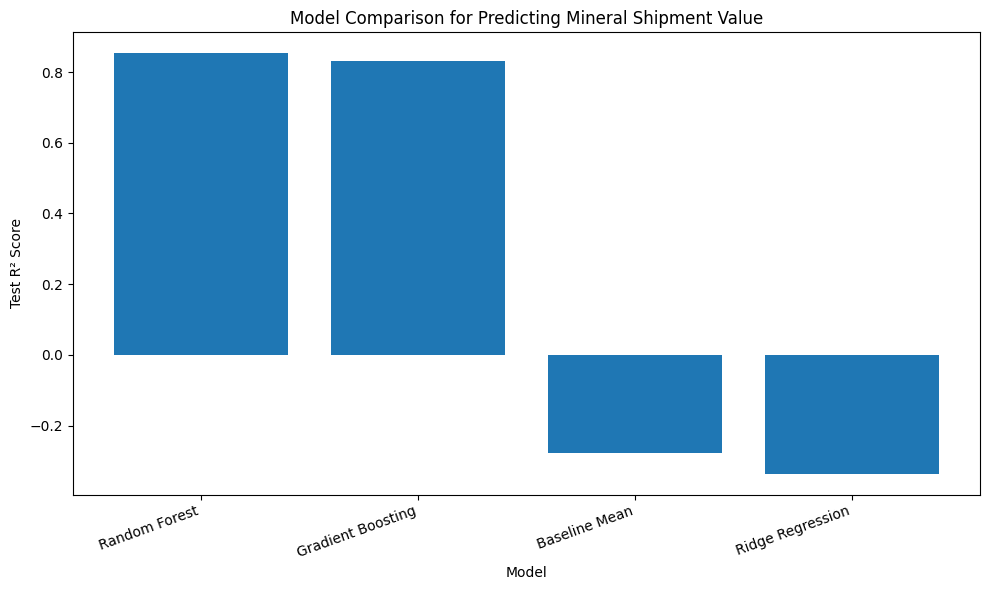

In [34]:
# Visualization: model comparison

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R² on actual value"]
)

plt.xlabel("Model")
plt.ylabel("Test R² Score")
plt.title("Model Comparison for Predicting Mineral Shipment Value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


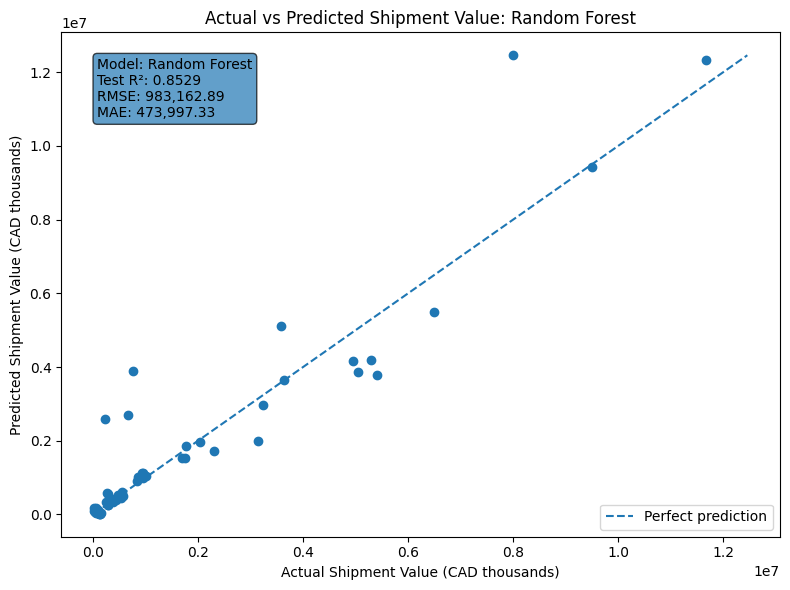

In [35]:
# Visualization: actual vs predicted values for best model

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_log = best_model.predict(X_test)

y_test_actual = np.expm1(y_test_log)
y_pred_actual = np.expm1(y_pred_log)

best_r2 = r2_score(y_test_actual, y_pred_actual)
best_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
best_mae = mean_absolute_error(y_test_actual, y_pred_actual)

plt.figure(figsize=(8, 6))

plt.scatter(y_test_actual, y_pred_actual)

min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Shipment Value (CAD thousands)")
plt.ylabel("Predicted Shipment Value (CAD thousands)")
plt.title(f"Actual vs Predicted Shipment Value: {best_model_name}")
plt.legend()

textstr = (
    f"Model: {best_model_name}\n"
    f"Test R²: {best_r2:.4f}\n"
    f"RMSE: {best_rmse:,.2f}\n"
    f"MAE: {best_mae:,.2f}"
)

plt.text(
    0.05,
    0.95,
    textstr,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.7)
)

plt.tight_layout()
plt.show()


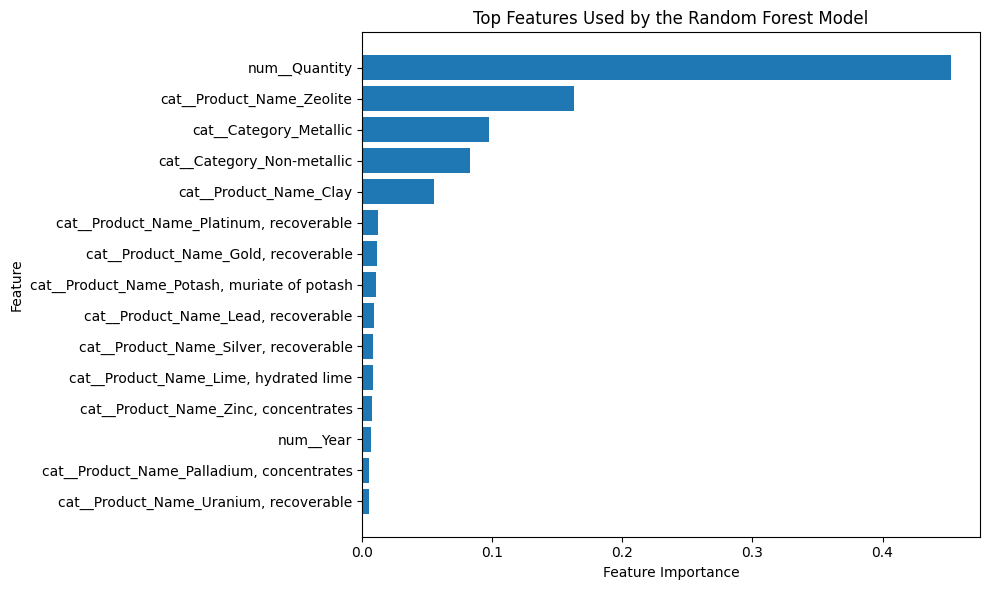

,Feature,Importance
0,num__Quantity,0.452308
47,cat__Product_Name_Zeolite,0.162789
50,cat__Category_Metallic,0.097734
51,cat__Category_Non-metallic,0.082800
2,cat__Product_Name_Clay,0.054985
33,"cat__Product_Name_Platinum, recoverable",0.012391
9,"cat__Product_Name_Gold, recoverable",0.011120
34,"cat__Product_Name_Potash, muriate of potash",0.010989
17,"cat__Product_Name_Lead, recoverable",0.009282
43,"cat__Product_Name_Silver, recoverable",0.008626


In [36]:
# only tree-based models show feature importances

if best_model_name in ["Random Forest", "Gradient Boosting"]:
    best_pipeline = trained_models[best_model_name]
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    fitted_model = best_pipeline.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()
    importances = fitted_model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(f"Top Features Used by the {best_model_name} Model")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(importance_df)
else:
    print(f"{best_model_name} does not provide simple feature importances.")


This improved model is definitely stronger than our earlier quantity-only regression. The baseline gives a floor to compare against, and the tree-based models, such as Random Forest and Gradient Boosting, test whether the data has non linear patterns that are worth capturing.

A high test R² for the best model means the included features contain meaningful predictive information, and the actual-vs-predicted plot shows how close the model's predictions are to the true shipment values.

One limitation is that the model may struggle with unseen minerals, as the same mineral appears in both train and test sets across different years. A stricter future test could hold out entire mineral products to evaluate whether the model generalizes to completely new minerals.


---
## Insights and Conclusions

We took a deep look at Canadian mineral production data in order to explore whether production volume, economic value, and mineral category are related in a significant way. We were able to utilize data preprocessing, exploratory analysis, hypothesis testing, and machine learning.

### Findings

**Finding 1: Metallic and non-metallic minerals operate at different scales of production.**

The Mann-Whitney U test confirmed that the two categories have a statistically significant difference in production quantity distributions. Our follow-up linear regression was able to quantify this as well. Metallic minerals are produced in quantities around 60% higher than non-metallic ones on average, which makes sense. Canada's mining sector is powered by high volume metallic mining operations such as iron ore and copper, and non-metallic minerals are usually produced in smaller quantities.

**Finding 2: Production volume does not predict economic value.**

The Pearson correlation between average production quantity and average shipment value across 50 matched minerals was almost zero. The linear regression confirmed this with an R² of almost 0. This result indicated that a mineral's value is determined by what it is, and not by its quantity. Gold and platinum generate enormous revenue despite lower volume, while bulk materials like sand and gravel are produced in very large quantities but have lower value per unit. When product identity was added as a feature, the model improved significantly, which supports the idea that material type matters more than material quantity.

**Finding 3: Canada's total mineral value has grown significantly since 2019.**

The one-sample t-test showed that the mean total value from 2020 to 2025 is significantly higher than the 2019 baseline. The trend regression estimated a growth rate of approximately 4.8 billion CAD per year. However, while there was growth, it was uneven throughout the period due to the current events of the time.

### Limitations

- The annual dataset covers only 7 years, which limits the long term analysis. A longer historical series would make us more confident in our conclusions. The train-test split for the Q2 model is also not as accurate because the dataset has only 50 products, R² ranged from -0.01 to -0.41 over random splits. The full-dataset R² of 0.0022 is more reliable and consistent with the Pearson r result.

### Takeaways

Our main takeaway is that its important to understand that the Canada mineral sector has two distinct catergories that behave differently in scale. In each category, the actual mineral is the main driver of value, including factors such as rarity, demand, and industrial use. Other factors such as quantity are not nearly as relevant. The data also tells us that this market is a growing sector since 2020.